**2.1　ARIMAによる日経平均株価の予測**

　本例では次のパッケージをインストールします。pmdarimaはARIMAモデルのみならず、他の時系列モデルを使用する際にも様々な機能を発揮するパッケージです。

In [ ]:
pip install pmdarima

　ひとつのみのセルを用いてpmdarimaのインストールした後、データ管理、数値計算用にpandas、データ取得のためのpandas_datareader、標本期間定義のためのdatetime、統計処理のためのstatsmodels、ARIMA推計に必要とされるpmdarima、そして図表用のライブラリであるmatplotlibをインポートします。

In [2]:
#[1]ライブラリーの読み込み
import pandas as pd
import pandas_datareader as data
import datetime
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #自己相関（ACF）偏自己相関（PACF）算出用ライブラリ
from pmdarima import arima #ARIMA推計用ライブラリ
from pmdarima.arima import auto_arima #階差次数決定用ライブラリ
from matplotlib import pyplot as plt
import yfinance as yf

　ライブラリの読み込み後、pandas_datareaderを用いて株価データを取得します。日経平均株価のティッカーコードは^NKXです。他の市場インデックス、個別銘柄のティッカーも上記のWEBサイトから検索可能です。ライブラリdatetimeを読み込むことにより、予め、標本期間の開始日、終了日を指定することができます。株価の予測は、勿論、日次データを用いて翌日や翌々日の予測を行うことは可能です。本例では、日次データを月中平均データに変換して予測作業を行います。

In [ ]:
#[2]株価データの取得
start=datetime.date(2000,1,1)#標本期間を2020年1月1日から
end=datetime.date(2026,5,31)#2026年5月31日までに指定
nikkei_data = yf.download('^N225', start=start, end=end)
nikkei = nikkei_data['Close']#終値のみを抽出
nikkei.name = 'nikkei'#Series名称を'nikkei'へ変更
nikkei = nikkei.resample(rule = "ME").mean()#日次データを月中平均値へ変換
#nikkei = nikkei.resample(rule = "W").mean()#日次データを週平均値へ変換
nikkei.head()

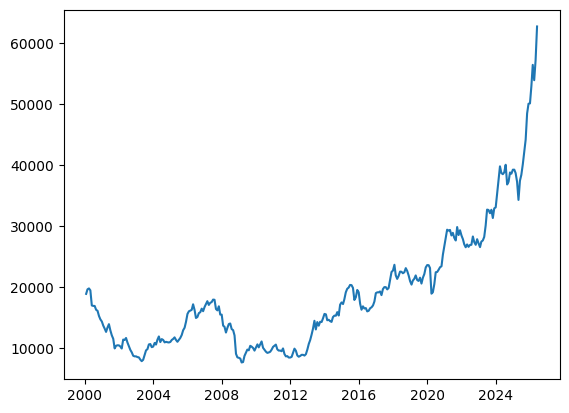

In [6]:
plt.plot(nikkei)

　時系列モデルは、自らの過去のデータのみから情報を取得し、将来の予測を行うための手法です。それゆえ、株価データが過去の自らの値にどの程度相関しているかを示す自己相関と、特定の過去の値のみにどれだけ影響を受けているかを示す偏自己相関は、AR、MAの次数p、qを選択する上で、極めて重要な情報となります。それゆえ、statmodelsのライブラリを用い、予めデータの階差系列（データの差分）を算出した上で、これらを可視化しておきます。
　次図は、相関係数「0」の周りに網掛けされた範囲内にデータがプロットされていれば、それは、自己相関、偏自己相関係数が統計的に有意に存在せず、データがランダムウォークしていることを意味します。逆に網掛けから大きく超えるデータは、有意な相関が存在することになります。本例では、当期の相関係数が1.0を示し、前月までは自己相関、偏自己相関が存在していることが視覚的に確認できますが、それより以前の値はほぼ網掛けの中で推移しており、当データがランダムウォークしていることを示しています。それゆえ、この時系列データを用いて予測を行う際には、定常性を確保することによる階差次数の決定が重要となります。


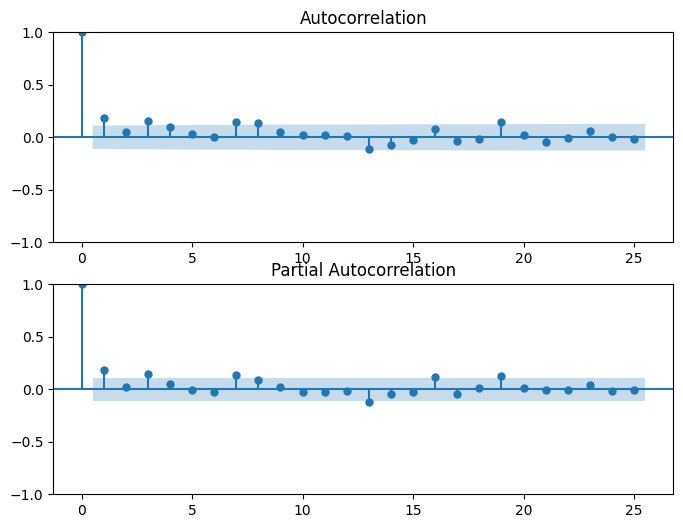

In [7]:
#[3]自己相関（ACF）と偏自己相関（PACF）の可視化
df= nikkei.diff().dropna()
fig, ax = plt.subplots(2, 1, figsize=(8, 6))
plot_acf(df, ax=ax[0])
plot_pacf(df, ax=ax[1])
plt.show()

　併せて、原データがトレンドを持つのか、季節的な変動を有するのか、そして原データとそれらとの残差を可視化します。次の4つのグラフは、最上段が現数値、二段目以降は順に抽出されたトレンド、季節的周期変動、現数値とトレンド＋季節変動の残差を示しています。これらの図を見ると、視覚的には、この株価データはトレンドと季節性双方を持っているように見えます。

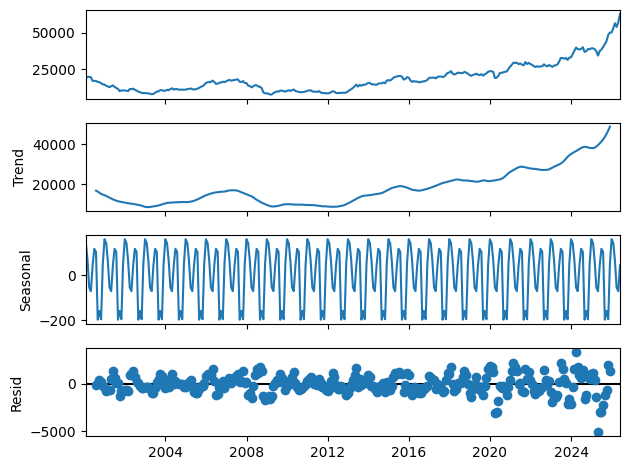

In [8]:
#[4]原データをトレンド・季節変動・残差へ分解
nikkei_interpolated = nikkei.interpolate(method='time')
sm.tsa.seasonal_decompose(nikkei_interpolated,period=12).plot()
plt.show()

　続いて、自己回帰項(p次)、差分階差数（d次）、移動平均項（q次）の次数を決定し、ARIMAモデルを推計します。本例では、データサイエンス・エンジニアのA・スミス氏が開発したpmdarimaライブラリ内のauto_arimaを用いて、これらの最適次数を求めます。pmdarimaのauto_arimaを用いる理由は、次数選択から推計までが自動化されていて便利であるためですが、定常性を手動で確認することを選好される方もいるかもしれません。こうした方々のために、拡張型ディッキー・フラー検定を用いる単位根検定による、データの定常性、非定常性の確認作業の手順は、拙著『Pythonで学ぶファイナンス論×データサイエンス』129—130頁をご覧ください。auto_arimaを用いる本例では、（p,d,q）の次数は(1,2,1)、そしてこのとき最小化されたAIC（赤池情報基準量）が5,138.9であることが示されています。

In [ ]:
#[5]次数選択とモデル・フィッティング
model=auto_arima(nikkei, seasonal=False, trace=True)
print(model.summary())

　最後に[5]においてフィッティングしたモデルを用い、未来24カ月間（2年間）の予測値3種類の値を算出します。予測値の中央値、95％信頼区間、99％信頼区間、がそれら3種類の予測値です。[5]においてモデル名をmodelと命名しているため、これに.predictを追記すれば予測値の中央値が算出されます。また、95％、99％信頼区間は、モデル名.predict()の（）内を[6]の通りに記述することで算出されます。

In [10]:
#[6]ARIMAモデルによる信頼区間の予測
pred,conf95 = model.predict(n_periods=24, return_conf_int=True,alpha=0.05)#未来24カ月予測値の95%信頼区間
pred,conf99 = model.predict(n_periods=24, return_conf_int=True,alpha=0.01)#未来24カ月予測値の99%信頼区間

　以下のコードは、上記３種類の予測結果とヒストリカル・データをプロットして可視化する手順です。

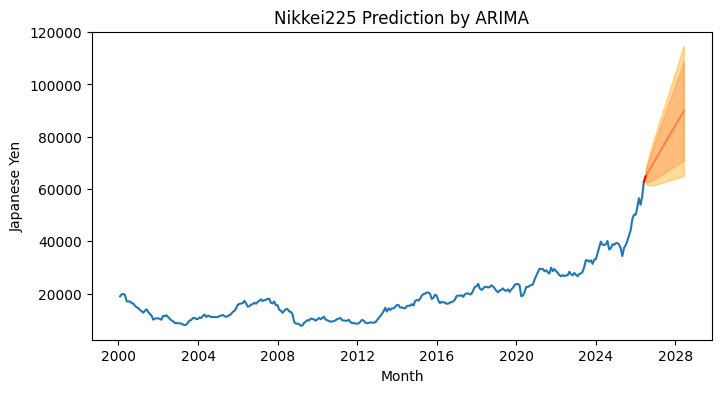

In [11]:
#[7]ARIMAモデルによる予測結果の可視化
plt.figure(figsize=(8, 4))
plt.plot(nikkei);
plt.plot(pred.index, pred, color='coral')#予測中心値の描画
plt.plot([nikkei.index[-1], pred.index[0]],[nikkei.iloc[-1].item(), pred.iloc[0]], color='red')
plt.fill_between(pred.index, conf95[:, 0], conf95[:, 1],color='red', alpha=0.2)#予測値の95%信頼区間の描画
plt.fill_between(pred.index, conf99[:, 0], conf99[:, 1],color='orange', alpha=0.4)#予測値の95%信頼区間の描画
plt.title('Nikkei225 Prediction by ARIMA')
plt.xlabel('Month');
plt.ylabel('Japanese Yen');

予測値算出結果の数値を、以下により表示します。

In [ ]:
pred